In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from warnings import filterwarnings
filterwarnings('ignore')

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.cm as cm

plt.style.use('seaborn-whitegrid')  # or simply 'seaborn-whitegrid' on older setups
sns.set_palette('viridis')

viridis_colors = cm.viridis(np.linspace(0, 1, 5))
primary_color = viridis_colors[0]
secondary_color = viridis_colors[1]
accent_color = viridis_colors[2]
danger_color = '#800000'
neutral_color = viridis_colors[4]
custom_palette = viridis_colors

In [3]:
df = pd.read_csv("Supply_Chain_Dataset.csv", encoding='latin-1')
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [4]:
df.shape

(180519, 53)

In [5]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Product Category Id',
       'Product De

# Exploratory Data Analysis (EDA)

In [6]:
print('rows, cols:', df.shape)
print('\ncolumns:')
print(df.columns.tolist())
print('\nNum duplicates:', df. duplicated().sum())
print('\nMissing values (top 20):')
print(df.isna().sum().sort_values(ascending=False).head(20))

rows, cols: (180519, 53)

columns:
['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Delivery Status', 'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id', 'Customer Lname', 'Customer Password', 'Customer Segment', 'Customer State', 'Customer Street', 'Customer Zipcode', 'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market', 'Order City', 'Order Country', 'Order Customer Id', 'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id', 'Order Item Product Price', 'Order Item Profit Ratio', 'Order Item Quantity', 'Sales', 'Order Item Total', 'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status', 'Order Zipcode', 'Product Card Id', 'Product Category Id', 'Product Description', 'Product Image', 'Product Name', 'Product Price', 'Produc

In [10]:
(df["Benefit per order"] == df["Order Profit Per Order"]).value_counts()

False    180519
dtype: int64

In [12]:
df[["Benefit per order","Order Profit Per Order"]]

,Benefit per order,Order Profit Per Order
0,1177.0,91.250000
1,8.0,-249.089996
2,19.0,-247.779999
3,65.0,22.860001
4,57.0,134.210007
...,...,...
180514,NaN,40.000000
180515,NaN,-613.770019
180516,NaN,141.110001
180517,NaN,186.229996


In [13]:
df["Product Status"].value_counts()

0    180519
Name: Product Status, dtype: int64

In [20]:
df['order date (DateOrders)'].info()

<class 'pandas.core.series.Series'>
Int64Index: 172765 entries, 0 to 180518
Series name: order date (DateOrders)
Non-Null Count   Dtype         
--------------   -----         
172765 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 2.6 MB


In [21]:
df['shipping date (DateOrders)'].info()

<class 'pandas.core.series.Series'>
Int64Index: 172765 entries, 0 to 180518
Series name: shipping date (DateOrders)
Non-Null Count   Dtype         
--------------   -----         
172765 non-null  datetime64[ns]
dtypes: datetime64[ns](1)
memory usage: 2.6 MB


In [14]:
# Data Cleaning
columns_to_drop = [
'Product Description',
'Product Image',
'Customer Email',
'Customer Password',
'Customer Fname',
'Customer Lname',
'Customer Street',
'Customer Zipcode',
'Order Zipcode',
'Longitude',
'Latitude',
'Order Item Cardprod Id',
'Order Item Id',
'Order Item Discount',
'Order Item Discount Rate',
'Order Item Product Price',
'Order Item Quantity',
'Order Item Total',
'Category Id',
'Department Id',
'Order Id',
'Order Customer Id',
'Customer Id',
'Product Card Id',
'Product Category Id',
'Product Status', # have only one value,
'Customer City',
'Order City',
'Order Country',
'Order State',
'Customer State',
'Market']
#dropping columns that are either fully missing, redundant, or have only one value (and thus no variance)
df = df.drop(columns=columns_to_drop)

In [16]:
#removing canceled orders since they are not relevant for delivery time analysis and may have different patterns than completed orders
df= df [df ['Delivery Status'] != 'Shipping canceled']

# Standard date conversion
for c in ['order date (DateOrders)', 'shipping date (DateOrders)']:
    df[c] = pd.to_datetime (df[c], errors='coerce', dayfirst=False)

#after data cleaning, let's check the overview again to see how the dataset has changed
print('rows, cols:', df.shape)
print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (172765, 21)

Missing values (top 5):
Benefit per order             172601
Type                               0
order date (DateOrders)            0
shipping date (DateOrders)         0
Product Price                      0
dtype: int64


In [22]:
df['Benefit per order']

0         1177.0
1            8.0
2           19.0
3           65.0
4           57.0
           ...  
180514       NaN
180515       NaN
180516       NaN
180517       NaN
180518       NaN
Name: Benefit per order, Length: 172765, dtype: float64

In [27]:
df.drop(columns = 'Benefit per order',inplace=True)

In [28]:
print('rows, cols:', df.shape)
print('\nMissing values (top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows, cols: (172765, 20)

Missing values (top 5):
Type                          0
Days for shipping (real)      0
shipping date (DateOrders)    0
Product Price                 0
Product Name                  0
dtype: int64


In [29]:
df.head()

,Type,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Delivery Status,Late_delivery_risk,Category Name,Customer Country,Customer Segment,Department Name,order date (DateOrders),Order Item Profit Ratio,Sales,Order Profit Per Order,Order Region,Order Status,Product Name,Product Price,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,314.640015,Advance shipping,0,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-31 22:56:00,0.29,327.75,91.250000,Southeast Asia,COMPLETE,Smart watch,327.75,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,311.359985,Late delivery,1,Sporting Goods,Puerto Rico,Consumer,Fitness,2018-01-13 12:27:00,-0.80,327.75,-249.089996,South Asia,PENDING,Smart watch,327.75,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,309.720001,Shipping on time,0,Sporting Goods,EE. UU.,Consumer,Fitness,2018-01-13 12:06:00,-0.80,327.75,-247.779999,South Asia,CLOSED,Smart watch,327.75,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,304.809998,Advance shipping,0,Sporting Goods,EE. UU.,Home Office,Fitness,2018-01-13 11:45:00,0.08,327.75,22.860001,Oceania,COMPLETE,Smart watch,327.75,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,298.250000,Advance shipping,0,Sporting Goods,Puerto Rico,Corporate,Fitness,2018-01-13 11:24:00,0.45,327.75,134.210007,Oceania,PENDING_PAYMENT,Smart watch,327.75,2018-01-15 11:24:00,Standard Class


In [31]:
for col in df.columns:
    if df[col].nunique() <10:
        print(f"{col} value counts")
        print(df[col].value_counts())
        print("\n")

Type value counts
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: Type, dtype: int64


Days for shipping (real) value counts
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: Days for shipping (real), dtype: int64


Days for shipment (scheduled) value counts
4    103153
2     33806
1     26513
0      9293
Name: Days for shipment (scheduled), dtype: int64


Delivery Status value counts
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: Delivery Status, dtype: int64


Late_delivery_risk value counts
1    98977
0    73788
Name: Late_delivery_risk, dtype: int64


Customer Country value counts
EE. UU.        106425
Puerto Rico     66340
Name: Customer Country, dtype: int64


Customer Segment value counts
Consumer       89420
Corporate      52528
Home Office    30817
Name: Customer Segment, dtype: int64


Order Status value counts
COMPLETE           59491
PENDING_PAYMENT    39832
PROCESSING       

In [36]:
# calculating order processing time and delay
df['Order Processing Time'] = (df['shipping date (DateOrders)'] - df ['order date (DateOrders)']).dt.days
df['Delay'] = df['Order Processing Time'] - df['Days for shipment (scheduled)']
df['Is_Delayed'] = df['Delay'] > 0
df['order_month'] = df['order date (DateOrders)'].dt.month
df['order_day'] = df['order date (DateOrders)'].dt.day_name()
df['order_hour'] = df['order date (DateOrders)'].dt.hour
df.describe()

,Days for shipping (real),Days for shipment (scheduled),Sales per customer,Late_delivery_risk,Order Item Profit Ratio,Sales,Order Profit Per Order,Product Price,Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,183.165948,0.572900,0.120801,203.828493,22.032360,141.278595,3.472816,0.539716,6.235511,11.482604
std,1.623446,1.373405,120.141871,0.494659,0.466610,132.392520,104.355313,139.862956,1.670187,1.494150,3.405593,6.927276
min,0.000000,0.000000,7.490000,0.000000,-2.750000,9.990000,-4274.979980,9.990000,0.000000,-2.000000,1.000000,0.000000
25%,2.000000,2.000000,104.379997,0.000000,0.080000,119.980003,7.030000,50.000000,2.000000,0.000000,3.000000,5.000000
50%,3.000000,4.000000,163.990005,1.000000,0.270000,199.919998,31.520000,59.990002,3.000000,1.000000,6.000000,11.000000
75%,5.000000,4.000000,247.399994,1.000000,0.360000,299.950012,64.800003,199.990005,5.000000,1.000000,9.000000,17.000000
max,6.000000,4.000000,1939.989990,1.000000,0.500000,1999.989990,911.799988,1999.989990,6.000000,4.000000,12.000000,23.000000


In [37]:
df['Is_Delayed'].value_counts()

True     94523
False    78242
Name: Is_Delayed, dtype: int64

In [38]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour'],
      dtype='object')

In [39]:
df["Order Profit Per Order"]

0          91.250000
1        -249.089996
2        -247.779999
3          22.860001
4         134.210007
             ...    
180514     40.000000
180515   -613.770019
180516    141.110001
180517    186.229996
180518    168.949997
Name: Order Profit Per Order, Length: 172765, dtype: float64

In [40]:
df["Order Profit Per Order"]>0

0          True
1         False
2         False
3          True
4          True
          ...  
180514     True
180515    False
180516     True
180517     True
180518     True
Name: Order Profit Per Order, Length: 172765, dtype: bool

In [41]:
df["Profitability Flag"] = np.where(df["Order Profit Per Order"]>0, "Profit", np.where(df["Order Profit Per Order"]<0, "Loss","Break-even"))
df["Profitability Flag"].value_counts()

Profit        139354
Loss           32295
Break-even      1116
Name: Profitability Flag, dtype: int64

In [42]:
df["Profitability Flag"].value_counts(normalize=True)

Profit        0.80661
Loss          0.18693
Break-even    0.00646
Name: Profitability Flag, dtype: float64

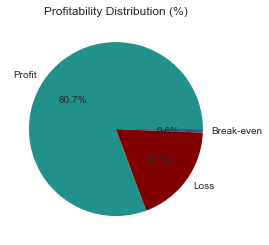

In [43]:
#visualization of profitability distribution
profit_counts = df ['Profitability Flag'].value_counts (normalize=True) * 100
profit_counts.plot(kind='pie', autopct='%1.1f%%', colors=[accent_color, danger_color, secondary_color])
plt.ylabel('')
plt.title('Profitability Distribution (%)')
plt.show()

In [55]:
delay_df = df[df['Delay'] > 0]
df[df['Delay'] > 0]['Delay'].quantile(0.90)

3.0

# Key Performance Indicator (KPIs)

In [44]:
def format_func(value):
    if value >= 1e6:
        return f'{value/1e6:.1f}M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'

delayed_df= df[df['Delay'] > 0]
metrics = {}
metrics['Total Orders'] = len(df)
metrics['Late Deliveries'] = len(delayed_df)
metrics['90% Delay (days)'] = delayed_df['Delay'].quantile(0.90)
metrics['On time Delivery %'] = (1 - float(metrics['Late Deliveries']) / metrics['Total Orders']) * 100
metrics['Late Delivery %'] = float(metrics['Late Deliveries']) / metrics['Total Orders'] * 100
metrics['Total Profit'] = format_func(df.loc[df['Order Profit Per Order'] > 0, 'Order Profit Per Order'].sum())
metrics['Total Loss due to delays'] = format_func(df.loc [df['Delay'] > 0, 'Order Profit Per Order'].sum())

print('\n-Business KPIs --\n')
for k, v in metrics.items():
    if isinstance(v, float):
        print(f"{k}: {v:.2f}")
    else:
        print(f"{k}: {v}")


-Business KPIs --

Total Orders: 172765
Late Deliveries: 94523
90% Delay (days): 3.00
On time Delivery %: 45.29
Late Delivery %: 54.71
Total Profit: 7.5M $
Total Loss due to delays: 2.1M $


In [56]:
profit_metrics = (
    df.groupby('Delay') ['Order Profit Per Order']
    .agg(mean_profit='mean', total_profit='sum',order_count='count')
    .reset_index()
)
profit_metrics

,Delay,mean_profit,total_profit,order_count
0,-2,23.360134,4.875961e+05,20873
1,-1,21.604769,4.476292e+05,20719
2,0,22.249118,8.154302e+05,36650
3,1,22.333227,1.194895e+06,53503
4,2,21.128491,5.821110e+05,27551
5,3,20.031412,1.356527e+05,6772
6,4,21.368783,1.431067e+05,6697


In [62]:
delay_distribution = (
    df['Delay'].value_counts(normalize=True).sort_index()*100
).reset_index()
delay_distribution

,index,Delay
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364



Profit Metrics by Delay Day:


,Delay,mean_profit,total_profit,order_count
0,-2,23.4,487596.1,20873
1,-1,21.6,447629.2,20719
2,0,22.2,815430.2,36650
3,1,22.3,1194894.7,53503
4,2,21.1,582111.0,27551
5,3,20.0,135652.7,6772
6,4,21.4,143106.7,6697



Delay Distribution (%):


,Delay_Days,Percentage
0,-2,12.081730
1,-1,11.992591
2,0,21.213788
3,1,30.968657
4,2,15.947096
5,3,3.919775
6,4,3.876364


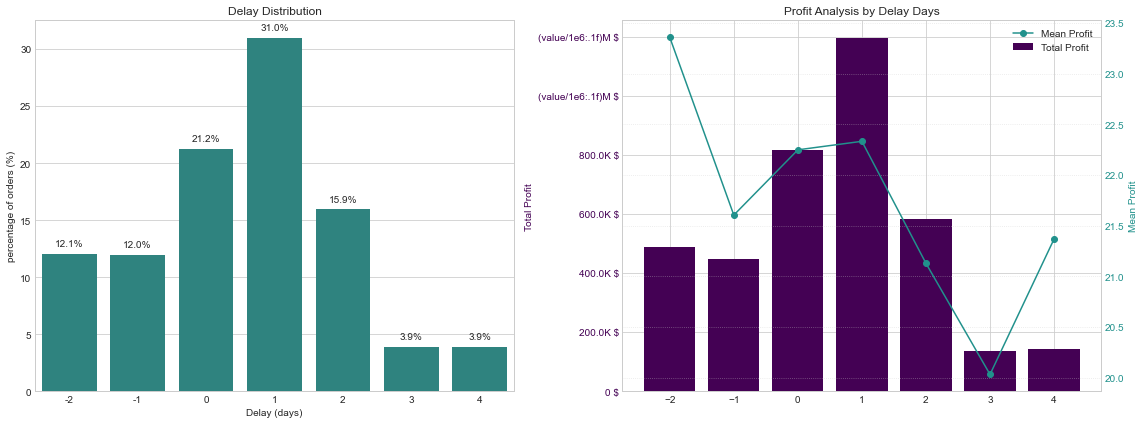

In [70]:
delay_distribution.columns = ['Delay_Days', 'Percentage']

print("\nProfit Metrics by Delay Day:")
display(profit_metrics.round(1))

print("\nDelay Distribution (%):")
display(delay_distribution)

fig, (ax1, ax2) = plt.subplots (1, 2, figsize=(16,6))

#First subplot: Delay Distribution
sns.barplot(x='Delay_Days', y='Percentage', data=delay_distribution, color = accent_color, ax=ax1)
ax1.set_title('Delay Distribution')
ax1.set_xlabel('Delay (days)')
ax1.set_ylabel('percentage of orders (%)')

#percentage text on bars
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center', va='bottom')
    
# Second subplot: Profit Analysis by Delay Days
ax2.set_ylabel("Total Profit", color = primary_color)
ax2.bar(profit_metrics['Delay'], profit_metrics['total_profit'], color=primary_color, label='Total Profit')
ax2.tick_params(axis='y', labelcolor=primary_color)

ax3 = ax2.twinx()

ax3.set_xlabel("Delay Days")
ax3.set_ylabel("Mean Profit", color = accent_color)
ax3.plot(profit_metrics['Delay'], profit_metrics['mean_profit'], marker='o', label='Mean Profit', color=accent_color)
ax3.tick_params(axis='y', labelcolor=accent_color)

# Format total profit axis to K $, M $
def format_func(value, tick_number):
    if value >= 1e6:
        return f'(value/1e6:.1f)M $'
    elif value >= 1e3:
        return f'{value/1e3:.1f}K $'
    else:
        return f'{value:.0f} $'
ax2.yaxis.set_major_formatter(ticker. FuncFormatter(format_func))
ax3.set_title("Profit Analysis by Delay Days")

lines, labels = ax3.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax3.legend(lines+lines2, labels+labels2, loc='upper right')
ax3.grid(True, linestyle=':', alpha = 0.5)

plt.tight_layout()
plt.show()

In [77]:
df.columns

Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Sales per customer', 'Delivery Status', 'Late_delivery_risk',
       'Category Name', 'Customer Country', 'Customer Segment',
       'Department Name', 'order date (DateOrders)', 'Order Item Profit Ratio',
       'Sales', 'Order Profit Per Order', 'Order Region', 'Order Status',
       'Product Name', 'Product Price', 'shipping date (DateOrders)',
       'Shipping Mode', 'Order Processing Time', 'Delay', 'Is_Delayed',
       'order_month', 'order_day', 'order_hour', 'Profitability Flag'],
      dtype='object')

# BottleNeck Detection 

In [ ]:
def compute_delay_pct_by_category(category):
    cat_df = df.groupby(category).agg(
        total_orders=('Delay', 'count'),
        late_orders=('Is_Delayed', 'sum')
    ).reset_index()
    cat_df['delay_pct'] = cat_df ['late_orders'] / cat_df ['total_orders'] * 100
    cat_df = cat_df.sort_values('delay_pct', ascending=False).head(10)
    return cat_df


In [78]:
compute_delay_pct_by_category('Customer Segment')

,Customer Segment,total_orders,late_orders,delay_pct
2,Home Office,30817,17060,55.359055
0,Consumer,89420,48855,54.635428
1,Corporate,52528,28608,54.462382


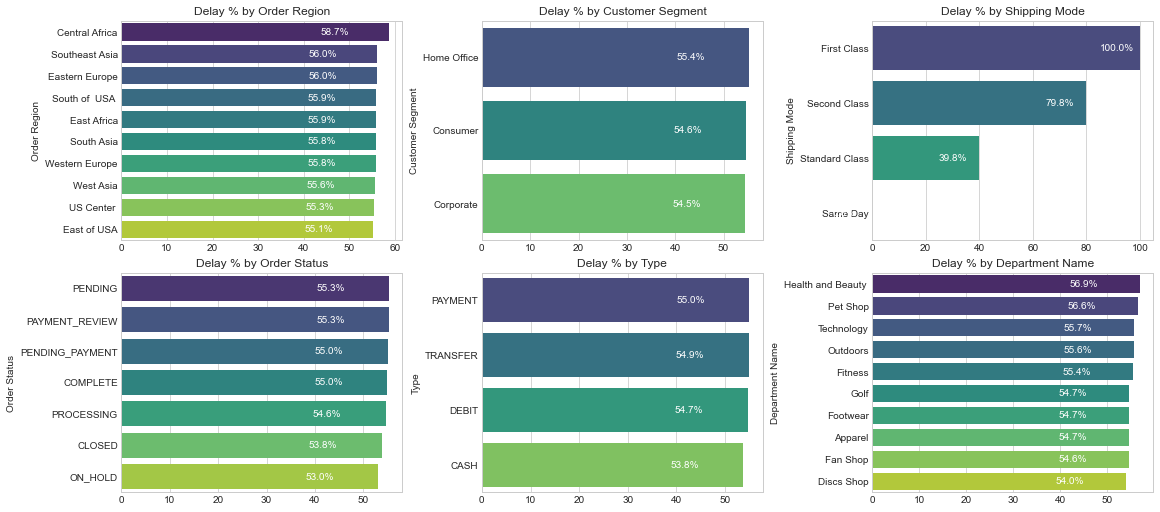

In [73]:

categories = ['Order Region', 'Customer Segment', 'Shipping Mode', 'Order Status', 'Type', 'Department Name']

fig, axes = plt.subplots (2, 3, figsize=(16, 7), constrained_layout=True)
axes = axes.flatten()

for ax, category in zip(axes, categories):
    cat_df = compute_delay_pct_by_category(category)
    sns.barplot(
        data=cat_df,
        x='delay_pct',
        y=category, 
        ax=ax, 
        palette = 'viridis'
)
    ax.set_title(f'Delay % by {category}')
    ax.set_xlabel('')
    ax.set_ylabel(category)
    for i, row in cat_df.reset_index().iterrows():
        ax.text(row['delay_pct']-15, i, f"{row['delay_pct']:.1f}%", va='center', fontsize=10, color = 'white')
plt.show()